<a href="https://colab.research.google.com/github/NakshatraBinoy/FUTURE_ML_01/blob/main/sales_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

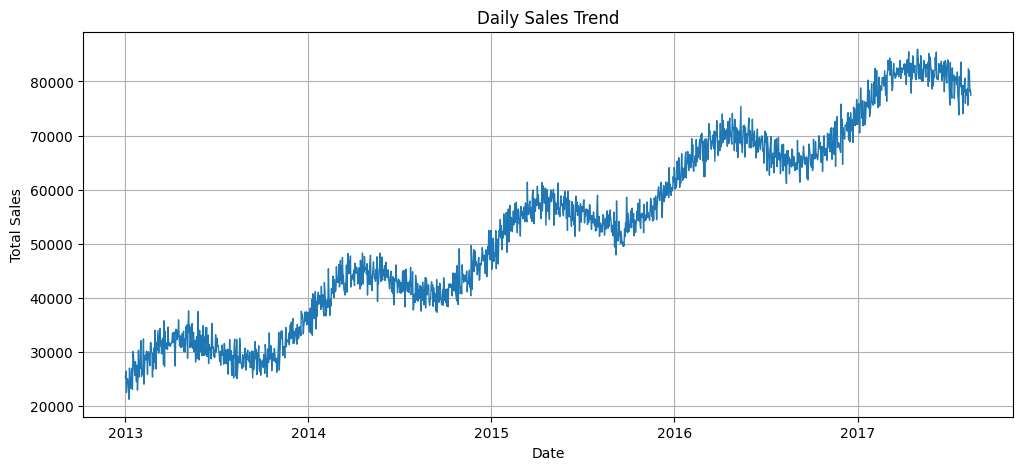

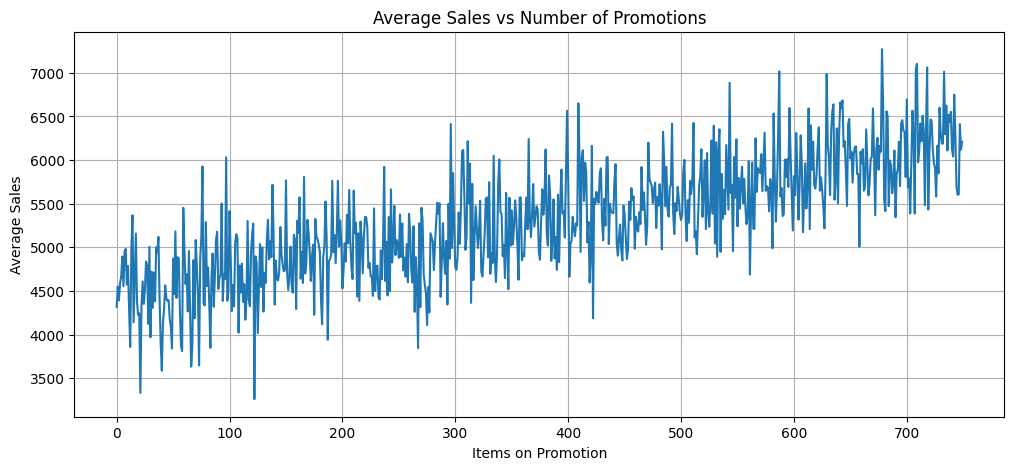

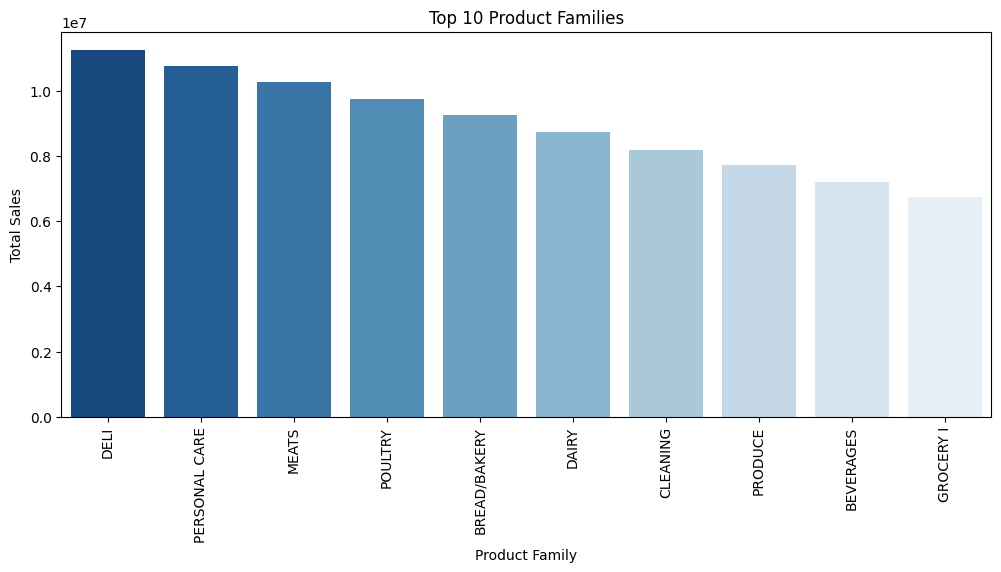

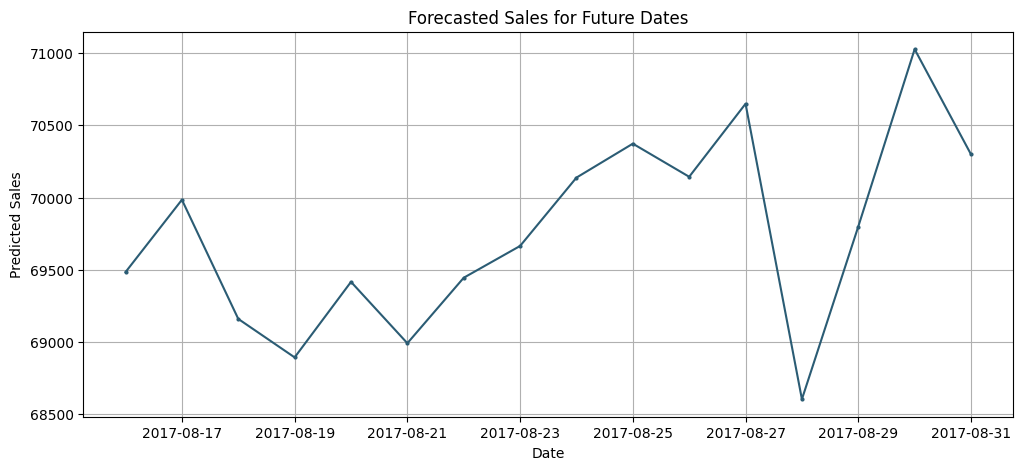

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
dates = pd.date_range(start="2013-01-01", end="2017-08-15", freq="D")
n_days = len(dates)

families = ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY',
            'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI']

data_list = []
for family in families:
    trend = np.linspace(1000, 5000, n_days) * (1 + (families.index(family) * 0.1))
    seasonality = 500 * np.sin(2 * np.pi * dates.dayofyear / 365.25)
    noise = np.random.normal(0, 300, n_days)

    promotions = np.random.randint(0, 750, n_days)
    promo_effect = promotions * 2.5

    sales = trend + seasonality + promo_effect + noise
    sales = np.clip(sales, 0, None)

    family_df = pd.DataFrame({
        "Date": dates,
        "Family": family,
        "Sales": sales,
        "OnPromotion": promotions
    })
    data_list.append(family_df)

df = pd.concat(data_list, ignore_index=True)

daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], linewidth=1)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

promo_sales = df.groupby('OnPromotion')['Sales'].mean().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(promo_sales['OnPromotion'], promo_sales['Sales'], color='tab:blue')
plt.title("Average Sales vs Number of Promotions")
plt.xlabel("Items on Promotion")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()

top_families = df.groupby('Family')['Sales'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(x='Family', y='Sales', data=top_families, palette='Blues_r', hue='Family', legend=False)
plt.title("Top 10 Product Families")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

df_encoded = pd.get_dummies(df, columns=['Family'], drop_first=True)

X = df_encoded.drop(columns=['Date', 'Sales'])
y = df_encoded['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

future_dates = pd.date_range(start="2017-08-16", end="2017-08-31", freq="D")
future_df = pd.DataFrame({
    "Date": np.repeat(future_dates, len(families)),
    "Family": families * len(future_dates),
    "OnPromotion": np.random.randint(50, 300, len(future_dates) * len(families))
})

future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Day'] = future_df['Date'].dt.day
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek
future_df_encoded = pd.get_dummies(future_df, columns=['Family'], drop_first=True)

future_df_encoded = future_df_encoded.reindex(columns=X.columns, fill_value=0)

future_preds = model.predict(future_df_encoded)
future_df['Predicted_Sales'] = future_preds

future_daily = future_df.groupby('Date')['Predicted_Sales'].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(future_daily['Date'], future_daily['Predicted_Sales'], color='#2b5c74', marker='o', markersize=2)
plt.title("Forecasted Sales for Future Dates")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.show()